In [ ]:
!apt-get update -qq
!apt-get install -y unrar
!pip install -q numpy pandas tifffile tqdm

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:7.0.7-1build1).
0 upgraded, 0 newly installed, 0 to remove and 118 not upgraded.


In [ ]:
from pathlib import Path

RAR_PATH = Path(
    "/content/drive/MyDrive/Stained_Montages.rar"
)

EXTRACT_ROOT = Path(
    "/content/BBBC045_raw"
)

EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("RAR file:", RAR_PATH)
print("Exists:", RAR_PATH.exists())

RAR file: /content/drive/MyDrive/Stained_Montages.rar
Exists: True


In [ ]:
import subprocess

if not RAR_PATH.exists():
    raise FileNotFoundError(
        f"RAR file not found:\n{RAR_PATH}"
    )

print("Extracting RAR...")
print("This may take a while.")

result = subprocess.run(
    [
        "unrar",
        "x",
        "-o+",
        str(RAR_PATH),
        str(EXTRACT_ROOT) + "/"
    ],
    text=True
)

if result.returncode != 0:
    raise RuntimeError(
        f"unrar failed with return code {result.returncode}"
    )

print()
print("Extraction finished.")
print("Extracted to:", EXTRACT_ROOT)

Extracting RAR...
This may take a while.

Extraction finished.
Extracted to: /content/BBBC045_raw


In [ ]:
from pathlib import Path

candidates = [
    p
    for p in EXTRACT_ROOT.rglob("Stained_Montages")
    if p.is_dir()
]

print("Candidates found:")

for p in candidates:
    print("   ", p)

if len(candidates) == 0:
    raise RuntimeError(
        "Could not find a folder named 'Stained_Montages'."
    )

INPUT_ROOT = candidates[0]

print()
print("Using:")
print(INPUT_ROOT)

Candidates found:
    /content/BBBC045_raw/Stained_Montages

Using:
/content/BBBC045_raw/Stained_Montages


In [ ]:
import re
from collections import defaultdict

MONTAGE_PATTERN = re.compile(
    r"^ch5_(\d+)\.tif$",
    re.IGNORECASE
)

montage_files = []

for path in INPUT_ROOT.rglob("*.tif"):

    # Ignore old generated single-cell directories
    if any(
        part.lower().endswith("_single_cells")
        for part in path.parts
    ):
        continue

    # ONLY ch5_NUMBER.tif
    if not MONTAGE_PATTERN.fullmatch(path.name):
        continue

    relative = path.relative_to(INPUT_ROOT)

    # Expected:
    # donor / cell_type / batch / ch5_N.tif
    if len(relative.parts) != 4:
        continue

    montage_files.append(path)


montage_files = sorted(montage_files)

print(
    f"True Ch5 brightfield montages found: "
    f"{len(montage_files)}"
)

True Ch5 brightfield montages found: 215


In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import tifffile

from tqdm.auto import tqdm


# ============================================================
# CONFIGURATION
# ============================================================

# INPUT_ROOT was automatically detected above

OUTPUT_ROOT = Path(
    "/content/BBBC045_BF_single_cells"
)

TILE_SIZE = 55

EXPECTED_MONTAGE_SIZE = (
    1650,
    1650
)

MONTAGE_PATTERN = re.compile(
    r"^ch5_(\d+)\.tif$",
    re.IGNORECASE
)


# ============================================================
# FIND ONLY TRUE CH5 MONTAGES
# ============================================================

montage_files = []


for path in INPUT_ROOT.rglob("*.tif"):

    # --------------------------------------------------------
    # Never process already-generated single cells
    # --------------------------------------------------------

    if any(
        part.lower().endswith("_single_cells")
        for part in path.parts
    ):
        continue


    # --------------------------------------------------------
    # Filename MUST be exactly:
    #
    # ch5_1.tif
    # ch5_2.tif
    # ch5_17.tif
    #
    # etc.
    # --------------------------------------------------------

    match = MONTAGE_PATTERN.fullmatch(
        path.name
    )

    if match is None:
        continue


    # --------------------------------------------------------
    # Expected BBBC045 structure:
    #
    # donor /
    #     cell_type /
    #         batch /
    #             ch5_N.tif
    # --------------------------------------------------------

    relative = path.relative_to(
        INPUT_ROOT
    )

    if len(relative.parts) != 4:

        print(
            "Skipping unexpected structure:",
            path
        )

        continue


    montage_files.append(
        path
    )


montage_files = sorted(
    montage_files
)


print()
print("=" * 80)
print(
    f"TRUE CH5 MONTAGES FOUND: "
    f"{len(montage_files)}"
)
print("=" * 80)
print()


# ============================================================
# EXTRACTION
# ============================================================

records = []

skipped_wrong_shape = []

skipped_padding_tiles = 0

total_possible_tiles = 0


for montage_path in tqdm(
    montage_files,
    desc="Extracting brightfield cells"
):


    # ========================================================
    # METADATA FROM FOLDER STRUCTURE
    # ========================================================

    relative = montage_path.relative_to(
        INPUT_ROOT
    )

    donor = relative.parts[0]

    cell_type = relative.parts[1]

    batch = relative.parts[2]


    # ========================================================
    # READ ORIGINAL FLOAT TIFF
    # ========================================================

    image = tifffile.imread(
        montage_path
    )


    # ========================================================
    # SAFETY CHECK
    # ========================================================

    if image.shape != EXPECTED_MONTAGE_SIZE:

        skipped_wrong_shape.append({
            "file": str(montage_path),
            "shape": str(image.shape)
        })

        print(
            f"\nSKIPPED:\n"
            f"{montage_path}\n"
            f"Expected {EXPECTED_MONTAGE_SIZE}, "
            f"got {image.shape}\n"
        )

        continue


    original_dtype = image.dtype


    # ========================================================
    # GRID
    # ========================================================

    n_rows = (
        image.shape[0]
        // TILE_SIZE
    )

    n_cols = (
        image.shape[1]
        // TILE_SIZE
    )


    assert n_rows == 30

    assert n_cols == 30


    # ========================================================
    # MONTAGE NUMBER
    # ========================================================

    montage_match = (
        MONTAGE_PATTERN.fullmatch(
            montage_path.name
        )
    )

    montage_number = int(
        montage_match.group(1)
    )


    # ========================================================
    # OUTPUT DIRECTORY
    # ========================================================

    output_dir = (
        OUTPUT_ROOT
        / donor
        / cell_type
        / batch
        / f"ch5_{montage_number}"
    )


    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # ========================================================
    # EXTRACT 55 × 55 TILES
    # ========================================================

    cell_counter = 0


    for row in range(30):


        y1 = row * TILE_SIZE

        y2 = y1 + TILE_SIZE


        for col in range(30):


            total_possible_tiles += 1


            x1 = col * TILE_SIZE

            x2 = x1 + TILE_SIZE


            tile = image[
                y1:y2,
                x1:x2
            ].copy()


            # =================================================
            # EMPTY / PADDING DETECTION
            #
            # Important:
            # Do NOT use contrast or std thresholds here.
            #
            # We only remove definite empty / zero padding.
            # =================================================

            finite = tile[
                np.isfinite(tile)
            ]


            if finite.size == 0:

                skipped_padding_tiles += 1

                continue


            if (
                np.max(
                    np.abs(finite)
                )
                <= 1e-12
            ):

                skipped_padding_tiles += 1

                continue


            # =================================================
            # THIS IS A VALID SINGLE-CELL TILE
            # =================================================

            cell_counter += 1


            filename = (

                f"{donor}_"
                f"{cell_type}_"
                f"{batch}_"
                f"ch5_{montage_number}_"
                f"cell_{cell_counter:04d}_"
                f"r{row:02d}_"
                f"c{col:02d}.tif"
            )


            output_path = (
                output_dir
                / filename
            )


            # =================================================
            # SAVE ORIGINAL PIXELS
            #
            # NO:
            # normalization
            # resizing
            # CLAHE
            # sharpening
            # PNG conversion
            #
            # Preserve the biological master image.
            # =================================================

            tifffile.imwrite(
                output_path,
                tile.astype(
                    original_dtype
                ),
                photometric="minisblack"
            )


            # =================================================
            # METADATA
            # =================================================

            records.append({

                "donor":
                    donor,

                "cell_type":
                    cell_type,

                "batch":
                    batch,

                "channel":
                    5,

                "montage_number":
                    montage_number,

                "montage_filename":
                    montage_path.name,

                "cell_number_in_montage":
                    cell_counter,

                "grid_row":
                    row,

                "grid_column":
                    col,

                # Original location:
                # 0 ... 899
                "grid_index":
                    row * 30 + col,

                "height":
                    55,

                "width":
                    55,

                "dtype":
                    str(
                        original_dtype
                    ),

                "min":
                    float(
                        np.min(tile)
                    ),

                "max":
                    float(
                        np.max(tile)
                    ),

                "mean":
                    float(
                        np.mean(tile)
                    ),

                "std":
                    float(
                        np.std(tile)
                    ),

                "source_montage":
                    str(
                        montage_path
                    ),

                "single_cell_path":
                    str(
                        output_path
                    )
            })


# ============================================================
# CREATE METADATA TABLE
# ============================================================

metadata = pd.DataFrame(
    records
)


OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


metadata_file = (
    OUTPUT_ROOT
    / "BBBC045_brightfield_metadata.csv"
)


metadata.to_csv(
    metadata_file,
    index=False
)


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 80)

print("BBBC045 BRIGHTFIELD EXTRACTION FINISHED")

print("=" * 80)

print()

print(
    "True Ch5 montages processed:",
    len(montage_files)
)

print(
    "Possible grid positions:",
    f"{total_possible_tiles:,}"
)

print(
    "Empty/padded positions skipped:",
    f"{skipped_padding_tiles:,}"
)

print(
    "Valid single cells extracted:",
    f"{len(metadata):,}"
)

print(
    "Wrong-size montages skipped:",
    len(skipped_wrong_shape)
)

print()

print(
    "Dataset location:"
)

print(
    OUTPUT_ROOT
)

print()

print(
    "Metadata:"
)

print(
    metadata_file
)


# ============================================================
# SUMMARY BY DONOR AND CELL TYPE
# ============================================================

if len(metadata) > 0:

    print()
    print("=" * 80)

    print(
        "CELLS BY DONOR / CELL TYPE"
    )

    print("=" * 80)

    summary = (

        metadata

        .groupby(
            [
                "donor",
                "cell_type"
            ]
        )

        .size()

        .rename(
            "number_of_cells"
        )

    )

    print(
        summary
    )


TRUE CH5 MONTAGES FOUND: 215



Extracting brightfield cells:   0%|          | 0/215 [00:00<?, ?it/s]


BBBC045 BRIGHTFIELD EXTRACTION FINISHED

True Ch5 montages processed: 215
Possible grid positions: 193,500
Empty/padded positions skipped: 93,395
Valid single cells extracted: 100,105
Wrong-size montages skipped: 0

Dataset location:
/content/BBBC045_BF_single_cells

Metadata:
/content/BBBC045_BF_single_cells/BBBC045_brightfield_metadata.csv

CELLS BY DONOR / CELL TYPE
donor   cell_type 
CRF022  B              533
        T             1816
        eosinophil     271
        monocyte       346
        neutrophil    1693
                      ... 
CRF59   B              166
        T             1273
        eosinophil     112
        monocyte         3
        neutrophil    1380
Name: number_of_cells, Length: 65, dtype: int64


In [ ]:
import random
import tifffile

all_cells = list(
    OUTPUT_ROOT.rglob("*.tif")
)

print(
    "Number of extracted TIFFs:",
    len(all_cells)
)

sample_files = random.sample(
    all_cells,
    min(20, len(all_cells))
)

print()

for path in sample_files:

    img = tifffile.imread(
        path
    )

    print(
        img.shape,
        img.dtype,
        path.name
    )

Number of extracted TIFFs: 100105

(55, 55) float32 CRF034_T_batch2_ch5_1_cell_0139_r06_c06.tif
(55, 55) float32 CRF130_B_batch2_ch5_1_cell_0060_r04_c07.tif
(55, 55) float32 CRF102_neutrophil_batch1_ch5_2_cell_0228_r07_c17.tif
(55, 55) float32 CRF074_T_batch1_ch5_1_cell_0082_r04_c05.tif
(55, 55) float32 CRF101_2015_monocyte_batch2_ch5_1_cell_0046_r03_c09.tif
(55, 55) float32 CRF034_neutrophil_batch2_ch5_1_cell_0822_r27_c11.tif
(55, 55) float32 CRF074_neutrophil_batch3_ch5_1_cell_0491_r16_c10.tif
(55, 55) float32 CRF132_T_batch3_ch5_1_cell_0071_r02_c10.tif
(55, 55) float32 CRF59_eosinophil_batch1_ch5_1_cell_0019_r02_c02.tif
(55, 55) float32 CRF102_neutrophil_batch2_ch5_4_cell_0295_r09_c24.tif
(55, 55) float32 CRF186_neutrophil_batch2_ch5_4_cell_0801_r26_c20.tif
(55, 55) float32 CRF132_T_batch2_ch5_1_cell_0558_r18_c17.tif
(55, 55) float32 CRF59_T_batch2_ch5_1_cell_0400_r15_c09.tif
(55, 55) float32 CRF132_T_batch2_ch5_1_cell_0126_r04_c05.tif
(55, 55) float32 CRF101_2014_neutrophil_batch2_

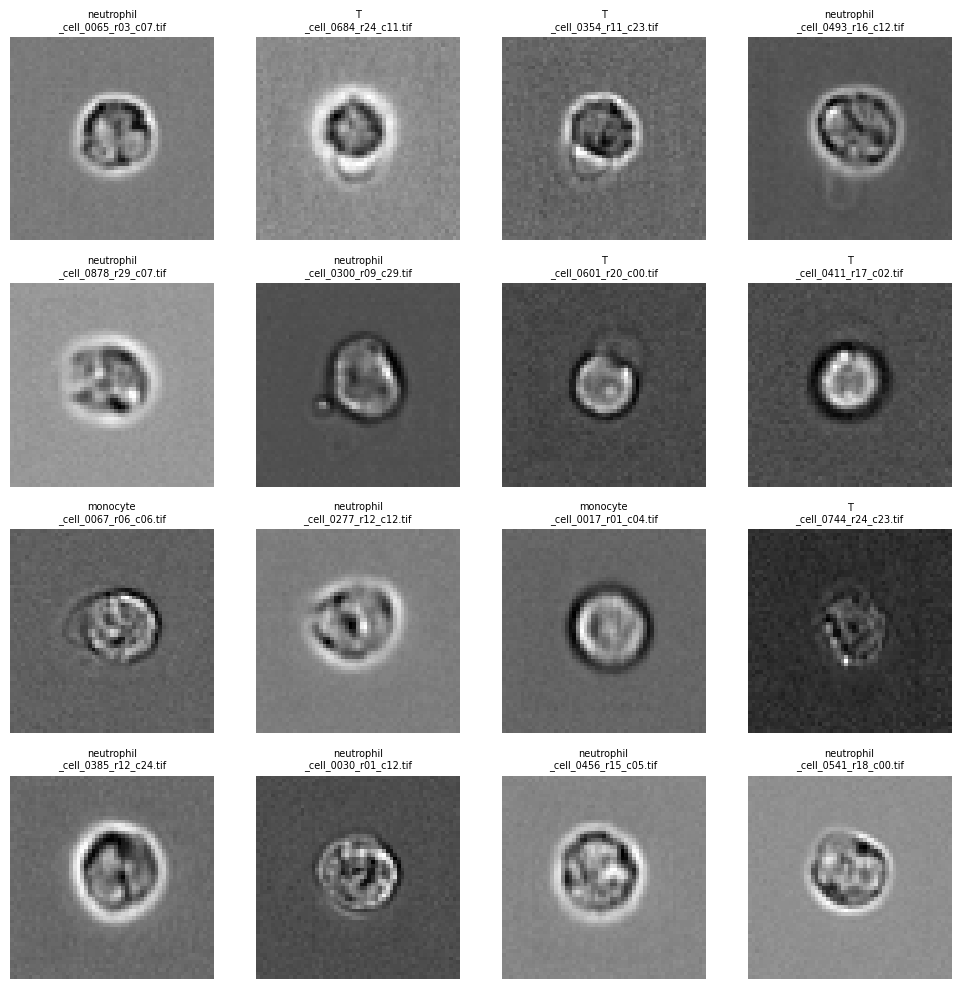

In [ ]:
import random
import matplotlib.pyplot as plt
import tifffile

sample_files = random.sample(
    all_cells,
    min(16, len(all_cells))
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(10, 10)
)

for ax, path in zip(
    axes.flat,
    sample_files
):

    img = tifffile.imread(
        path
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        path.parent.parent.parent.name
        + "\n"
        + path.name[-22:],
        fontsize=7
    )

    ax.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

p = "/content/BBBC045_BF_single_cells/BBBC045_brightfield_metadata.csv"

df = pd.read_csv(p)

print("shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())

print("\nfirst 5 rows:")
display(df.head())

shape: (100105, 19)

columns:
['donor', 'cell_type', 'batch', 'channel', 'montage_number', 'montage_filename', 'cell_number_in_montage', 'grid_row', 'grid_column', 'grid_index', 'height', 'width', 'dtype', 'min', 'max', 'mean', 'std', 'source_montage', 'single_cell_path']

first 5 rows:


,donor,cell_type,batch,channel,montage_number,montage_filename,cell_number_in_montage,grid_row,grid_column,grid_index,height,width,dtype,min,max,mean,std,source_montage,single_cell_path
0,CRF022,B,batch1,5,1,ch5_1.tif,1,0,0,0,55,55,float32,0.003021,0.003891,0.003447,0.000070,/content/BBBC045_raw/Stained_Montages/CRF022/B...,/content/BBBC045_BF_single_cells/CRF022/B/batc...
1,CRF022,B,batch1,5,1,ch5_1.tif,2,0,1,1,55,55,float32,0.002884,0.004517,0.003456,0.000147,/content/BBBC045_raw/Stained_Montages/CRF022/B...,/content/BBBC045_BF_single_cells/CRF022/B/batc...
2,CRF022,B,batch1,5,1,ch5_1.tif,3,0,2,2,55,55,float32,0.002945,0.004242,0.003445,0.000104,/content/BBBC045_raw/Stained_Montages/CRF022/B...,/content/BBBC045_BF_single_cells/CRF022/B/batc...
3,CRF022,B,batch1,5,1,ch5_1.tif,4,0,3,3,55,55,float32,0.002869,0.004318,0.003449,0.000116,/content/BBBC045_raw/Stained_Montages/CRF022/B...,/content/BBBC045_BF_single_cells/CRF022/B/batc...
4,CRF022,B,batch1,5,1,ch5_1.tif,5,0,4,4,55,55,float32,0.002945,0.004471,0.003462,0.000145,/content/BBBC045_raw/Stained_Montages/CRF022/B...,/content/BBBC045_BF_single_cells/CRF022/B/batc...
